# Deep Learning in Medicine Spring 2025

## Homework 3 - Sequence modeling

Hi! This homework aims to let you get acquianted with how sequence modelling in Deep Learning can be utilized for the biology domain. 

We will be utilizing existing public datasets and performing 4 separate steps with Torch.

Our data is related to enhancers, genomic elements which can alter the levels of gene expression.

There are 4 tasks:

1. RNNs/LSTMs for sequence modelling - You will be tasked to utilize existing PyTorch infrastructure and LSTMs to perform sequence classification (40 points).

2. Transformers - Implement a transformer with a classification head, compare and contrast with the LSTM architecture in terms of accuracy, memory requirements, and runtime. (40 points).

3. Hyperparameter optimization - Use one of your two Transformers alongside a hyperparameter optimization library to explore different hyperparameter and potentially increase performance. (30 points).

4. Extracting and exploring embeddings from pre-trained SSL models - Do the big models truly understand what is an enhancer? If so, their latent representations of such sequences should be meaningful. (30 points).

The maximum you can get for the whole homework is 140. This means that you can choose to solve two assignments fully and one partially depending on your interests and/or familiarity.




### Dataset loading

Make sure you install the [https://github.com/ML-Bioinfo-CEITEC/genomic_benchmarks](genomic-benchmarks) package with ```pip install genomic-benchmarks```. Make sure your gdown package is updated!

#### Explore the dataset

In [3]:
import os
import zipfile
from pathlib import Path

data_dir = Path("./data/human_enhancers_ensembl")

if not data_dir.exists():
    print("Downloading dataset...")
    os.system(
        'curl -L "https://www.dropbox.com/scl/fi/xpdx4rs85klgnqsf2h3ru/human_enhancers_ensembl.zip?rlkey=d781kmzwf1i661y2j6lvutsy6&st=ii3kyekl&dl=0&raw=1" --output dataset.zip'
    )
    with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
        zip_ref.extractall("./data")
    os.remove("dataset.zip")  
    print("Download and extraction done.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    17  100    17    0     0     41      0 --:--:-- --:--:-- --:--:--    41
100   491    0   491    0     0    524      0 --:--:-- --:--:-- --:--:--   524
100 48.7M  100 48.7M    0     0  31.4M      0  0:00:01  0:00:01 --:--:--  189M


Download and extraction done.


As you can see the dataset is quite large, so make sure you have GPU access when using it.

In [4]:
from torch.utils.data import Dataset
from pathlib import Path

class GenomicClfDataset(Dataset):
    def __init__(self, split_path):
        self.all_paths = []
        self.all_labels = []
        label_mapper = {}

        for i, x in enumerate(split_path.iterdir()):
            if x.is_dir():  
                label_mapper[x.stem] = i

        for label_type in label_mapper:
            label_dir = split_path / label_type
            for x in label_dir.iterdir():
                if x.is_file():  
                    self.all_paths.append(x)
                    self.all_labels.append(label_mapper[label_type])

    def __len__(self):
        return len(self.all_paths)

    def __getitem__(self, idx):
        txt_path = self.all_paths[idx]
        with open(txt_path, "r") as f:
            content = f.read()
        return content, self.all_labels[idx]


In [5]:
from pathlib import Path

train_ds = GenomicClfDataset(Path("./data/human_enhancers_ensembl/train"))
test_ds = GenomicClfDataset(Path("./data/human_enhancers_ensembl/test"))

print("Train size:", len(train_ds))
print("Test size:", len(test_ds))

Train size: 123872
Test size: 30970


#### Load the dataset

Luckily the repository gives us ample instructions on how to load the dataset

#### Dataset exploration (5 points)

Time to take a look at the data!

Use your code to check:

1. Number of examples in train and test datasets (A simple print will do)
2. Structure of examples (You can use)
3. Maximum of sequences (Important padding length!)
4. Number of nucleotides, di-nucleotides, trinucleotides (Tip: You can use defaultdict!).

In [7]:
print("train:", len(train_ds))
print("test:", len(test_ds))


train: 123872
test: 30970


In [ ]:
x, y = train_ds[0]
print("Example sequence (first 100 characters):", x[:100])
print("Label:", y)


Example sequence (first 100 characters): CGGAAGGTTTACACTTCAAGGCTGACACTATTAAGTCTTCAGCATCAGAAAGTACTGTATGCAGTAACCACAAAGTAACCAGAAAGGGGCTGGCTTCTAG
Label: 0


In [ ]:
max_len = max(len(seq) for seq, _ in train_ds)
print("Maximum sequence length:", max_len)


Maximum sequence length: 573


In [7]:
from collections import defaultdict

mono_counts = defaultdict(int)
di_counts = defaultdict(int)
tri_counts = defaultdict(int)

for seq, _ in train_ds:
    seq = seq.strip().upper()
    for i in range(len(seq)):
        mono_counts[seq[i]] += 1
        if i < len(seq) - 1:
            di_counts[seq[i:i+2]] += 1
        if i < len(seq) - 2:
            tri_counts[seq[i:i+3]] += 1

print("Number of nucleotides:", len(mono_counts), "(Example:", dict(list(mono_counts.items())[:5]), ")")
print("Number of dinucleotides:", len(di_counts), "(Example:", dict(list(di_counts.items())[:5]), ")")
print("Number of trinucleotides:", len(tri_counts), "(Example:", dict(list(tri_counts.items())[:5]), ")")


Number of nucleotides: 5 (Example: {'C': 7297034, 'T': 9368949, 'G': 7304049, 'A': 9347315, 'N': 17581} )
Number of dinucleotides: 17 (Example: {'CT': 2403568, 'TG': 2474308, 'GA': 2022950, 'AG': 2398436, 'GC': 1592909} )
Number of trinucleotides: 65 (Example: {'CTG': 742117, 'TGA': 654675, 'GAG': 607613, 'AGC': 509212, 'GCG': 113837} )


#### Generate a separate dataset with non-overlapping n-nucleotides (5 points)

We will use those to test the difference of utilizing different levels of encoding our bases (by 1, 2, 3).

Make sure to generate the vocabulary and any special tokens you might need.

In [6]:
def tokenize_sequence(seq, n):
    seq = seq.strip().upper()
    return [seq[i:i+n] for i in range(0, len(seq) - n + 1, n)]



In [7]:
def build_vocab(dataset, n):
    vocab = set()
    for seq, _ in dataset:
        tokens = tokenize_sequence(seq, n)
        vocab.update(tokens)
    return sorted(vocab)

In [8]:
def build_tokenized_dataset(dataset, n, vocab):
    
    token_to_id = {token: idx for idx, token in enumerate(vocab)}
    tokenized_seqs = []

    for seq, label in dataset:
        tokens = tokenize_sequence(seq, n)
        token_ids = [token_to_id[tok] for tok in tokens if tok in token_to_id]
        tokenized_seqs.append((token_ids, label))

    return tokenized_seqs, token_to_id


In [9]:
mono_vocabulary = build_vocab(train_ds, 1)
di_vocabulary = build_vocab(train_ds, 2)
tri_vocabulary = build_vocab(train_ds, 3)

mono_dataset, mono_token_to_id = build_tokenized_dataset(train_ds, 1, mono_vocabulary)
di_dataset, di_token_to_id = build_tokenized_dataset(train_ds, 2, di_vocabulary)
tri_dataset, tri_token_to_id = build_tokenized_dataset(train_ds, 3, tri_vocabulary)

print("1-mer:", mono_dataset[0])
print("2-mer:", di_dataset[0])
print("3-mer:", tri_dataset[0])


1-mer: ([2, 1, 1, 1, 0, 2, 1, 1, 1, 0, 2, 1, 2, 2, 2, 1, 0, 1, 4, 2, 0, 4, 2, 2, 2, 2, 4, 1, 1, 4, 2, 2, 2, 0, 2, 1, 1, 4, 1, 1, 2, 2, 0, 1, 2, 2, 1, 1, 1, 1, 1, 0, 2, 4, 4, 2, 1, 1, 0, 4, 1, 1, 2, 4, 4, 2, 4, 1, 1, 1, 2, 2, 0, 0, 4, 1, 1, 4, 2, 1, 2, 1, 4, 2, 2, 2, 1, 1, 2, 2, 1, 1, 2, 0, 2, 2, 2, 0, 4, 4, 4, 2, 2, 4, 2, 1, 1, 4, 2, 2, 2, 4, 1, 1, 4, 2, 2, 2, 0, 4, 0, 4, 0, 2, 2, 2, 4, 1, 4, 2, 2, 1, 2, 1, 4, 0, 1, 2, 2, 0, 2, 2, 1, 1, 4, 2, 0, 0, 4, 4, 2, 2, 2, 0, 0, 1, 1, 1, 0, 0, 0, 0, 4, 4, 2, 0, 4, 4, 4, 1, 1, 0, 0, 0, 2, 2, 0, 0, 0, 0, 4, 0, 0, 4, 2, 4, 4, 4, 4, 0, 2, 2, 2, 0, 2, 1, 1, 0, 2, 2, 1, 1, 4, 2, 2, 1, 2, 2, 0, 1, 4, 2, 1, 4, 4, 1, 0, 0, 2, 2, 2, 1, 1, 4, 2, 2, 4, 2, 4, 2, 4, 2, 2, 2, 2, 2, 4, 4, 4, 2], 0)
2-mer: ([9, 5, 2, 5, 4, 9, 10, 9, 1, 15, 3, 10, 10, 14, 7, 10, 8, 9, 7, 5, 10, 1, 10, 5, 5, 4, 11, 15, 5, 3, 5, 11, 15, 14, 5, 10, 0, 14, 7, 9, 9, 15, 10, 5, 10, 5, 8, 10, 8, 16, 15, 11, 9, 7, 10, 11, 5, 15, 10, 3, 3, 2, 10, 14, 15, 9, 9, 13, 6, 8, 10, 5, 15, 0, 16, 

### Train a PyTorch LSTM single-layer LSTM model to classify sequences (15 points)

In [67]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import random
class TokenizedSeqDataset(Dataset):
    def __init__(self, data):
        self.data = data  

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        tokens, label = self.data[idx]
        return torch.tensor(tokens, dtype=torch.long), torch.tensor(label, dtype=torch.long)



In [68]:
def collate_fn(batch):
    seqs, labels = zip(*batch)
    seqs_padded = pad_sequence(seqs, batch_first=True, padding_value=0)
    return seqs_padded, torch.tensor(labels)
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)              
        _, (h_n, _) = self.lstm(x)         
        out = self.classifier(h_n.squeeze(0))  
        return out


In [69]:
train_data = TokenizedSeqDataset(mono_dataset)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=collate_fn)
vocab_size = len(mono_token_to_id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(vocab_size=vocab_size).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [18]:
train_data = TokenizedSeqDataset(mono_dataset)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=collate_fn)
vocab_size = len(mono_token_to_id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(vocab_size=vocab_size).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):  
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch in train_loader:
        x_batch, y_batch = [b.to(device) for b in batch]
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    acc = correct / total
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | Accuracy: {acc:.4f}")


Epoch 1 | Loss: 2675.5665 | Accuracy: 0.5043
Epoch 2 | Loss: 2638.2428 | Accuracy: 0.5315
Epoch 3 | Loss: 2111.5091 | Accuracy: 0.7239
Epoch 4 | Loss: 1780.7923 | Accuracy: 0.7851
Epoch 5 | Loss: 1663.0507 | Accuracy: 0.8031


#### Calculate AUC on the testing set for your model and plot the loss curve (5 points)

In [22]:

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
test_data = TokenizedSeqDataset(mono_dataset)  
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collate_fn)
loss_history = []

for epoch in range(20):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch in train_loader:
        x_batch, y_batch = [b.to(device) for b in batch]
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    acc = correct / total
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Accuracy: {acc:.4f}")




Epoch 1 | Loss: 0.3579 | Accuracy: 0.8429
Epoch 2 | Loss: 0.3492 | Accuracy: 0.8481
Epoch 3 | Loss: 0.3413 | Accuracy: 0.8522
Epoch 4 | Loss: 0.3337 | Accuracy: 0.8568
Epoch 5 | Loss: 0.3270 | Accuracy: 0.8599
Epoch 6 | Loss: 0.3185 | Accuracy: 0.8640
Epoch 7 | Loss: 0.3107 | Accuracy: 0.8684
Epoch 8 | Loss: 0.3021 | Accuracy: 0.8728
Epoch 9 | Loss: 0.2947 | Accuracy: 0.8765
Epoch 10 | Loss: 0.2868 | Accuracy: 0.8812
Epoch 11 | Loss: 0.2790 | Accuracy: 0.8846
Epoch 12 | Loss: 0.2719 | Accuracy: 0.8885
Epoch 13 | Loss: 0.2637 | Accuracy: 0.8921
Epoch 14 | Loss: 0.3963 | Accuracy: 0.8189
Epoch 15 | Loss: 0.4644 | Accuracy: 0.7784
Epoch 16 | Loss: 0.4627 | Accuracy: 0.7798
Epoch 17 | Loss: 0.4680 | Accuracy: 0.7775
Epoch 18 | Loss: 0.4660 | Accuracy: 0.7789
Epoch 19 | Loss: 0.5003 | Accuracy: 0.7561
Epoch 20 | Loss: 0.5329 | Accuracy: 0.7330


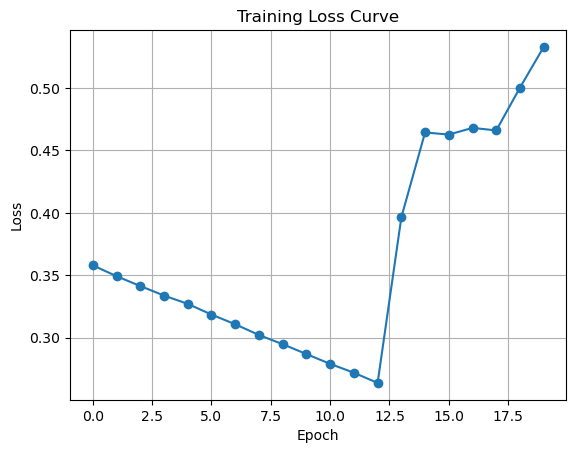

In [23]:
plt.plot(loss_history, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [24]:
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        x_batch, y_batch = [b.to(device) for b in batch]
        logits = model(x_batch)
        probs = torch.softmax(logits, dim=1)[:, 1]  
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
auc = roc_auc_score(all_labels, all_probs)
print(f"AUC on test set: {auc:.4f}")


AUC on test set: 0.8121


#### Repeat this exercise using an n-nucleotide representation of your choosing. Compare and contrast the accuracy, AUC, stability, training time, memory requirements, and inference time of your model (10 points)

In [70]:
mono_dataset, mono_token_to_id = build_tokenized_dataset(train_ds, 1, mono_vocabulary)
di_dataset, di_token_to_id = build_tokenized_dataset(train_ds, 2, di_vocabulary)
tri_dataset, tri_token_to_id = build_tokenized_dataset(train_ds, 3, tri_vocabulary)
mono_data = TokenizedSeqDataset(mono_dataset)
di_data = TokenizedSeqDataset(di_dataset)
tri_data = TokenizedSeqDataset(tri_dataset)


In [71]:
import time
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score
import psutil

def train_and_evaluate(dataset, vocab_size, name="1-mer"):
    print(f"\n== Training on {name} ==")

    loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    model = LSTMClassifier(vocab_size).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    loss_history = []
    start_train = time.time()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(5):
        model.train()
        total_loss = 0
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

    end_train = time.time()
    training_time = end_train - start_train

    if torch.cuda.is_available():
        mem_used = torch.cuda.max_memory_allocated() / 1024**2  # MB
    else:
        mem_used = psutil.Process().memory_info().rss / 1024**2  # MB

    model.eval()
    start_infer = time.time()
    preds, probs, labels = [], [], []
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        with torch.no_grad():
            output = model(x_batch)
            prob = F.softmax(output, dim=1)[:, 1].cpu().numpy()
            pred = output.argmax(dim=1).cpu().numpy()
        preds.extend(pred)
        probs.extend(prob)
        labels.extend(y_batch.numpy())
    end_infer = time.time()

    acc = accuracy_score(labels, preds)
    auc = roc_auc_score(labels, probs)
    infer_time = end_infer - start_infer

    stability = np.std(loss_history[-3:])  

    print(f"[{name}] Accuracy: {acc:.4f}, AUC: {auc:.4f}, Train time: {training_time:.2f}s, Inference: {infer_time:.2f}s, Mem: {mem_used:.2f} MB, Stability: {stability:.6f}")

    return {
        "name": name,
        "acc": acc,
        "auc": auc,
        "loss": loss_history,
        "train_time": training_time,
        "infer_time": infer_time,
        "memory": mem_used,
        "stability": stability
    }



In [72]:
results = []
results.append(train_and_evaluate(mono_data, len(mono_token_to_id), "1-mer"))
results.append(train_and_evaluate(di_data, len(di_token_to_id), "2-mer"))
results.append(train_and_evaluate(tri_data, len(tri_token_to_id), "3-mer"))



== Training on 1-mer ==
Epoch 1 | Loss: 0.6913
Epoch 2 | Loss: 0.6796
Epoch 3 | Loss: 0.6600
Epoch 4 | Loss: 0.5495
Epoch 5 | Loss: 0.4497
[1-mer] Accuracy: 0.8149, AUC: 0.8939, Train time: 75.29s, Inference: 9.01s, Mem: 12681.01 MB, Stability: 0.085893

== Training on 2-mer ==
Epoch 1 | Loss: 0.6833
Epoch 2 | Loss: 0.6787
Epoch 3 | Loss: 0.6150
Epoch 4 | Loss: 0.5380
Epoch 5 | Loss: 0.5024
[2-mer] Accuracy: 0.7763, AUC: 0.8584, Train time: 50.19s, Inference: 6.15s, Mem: 12542.59 MB, Stability: 0.046990

== Training on 3-mer ==
Epoch 1 | Loss: 0.6908
Epoch 2 | Loss: 0.5910
Epoch 3 | Loss: 0.5089
Epoch 4 | Loss: 0.4758
Epoch 5 | Loss: 0.4474
[3-mer] Accuracy: 0.8120, AUC: 0.8923, Train time: 47.40s, Inference: 5.27s, Mem: 12496.99 MB, Stability: 0.025109


In [73]:
import pandas as pd

df = pd.DataFrame(results)
df = df[["name", "acc", "auc", "train_time", "infer_time", "memory", "stability"]]
display(df)



,name,acc,auc,train_time,infer_time,memory,stability
0,1-mer,0.814890,0.893881,75.294865,9.011222,12681.012695,0.085893
1,2-mer,0.776317,0.858450,50.193264,6.149929,12542.591797,0.046990
2,3-mer,0.811959,0.892326,47.399534,5.267331,12496.986328,0.025109


1-meter has the highest accuracy, but also the highest training time and largest memory.

### Training a Transformer (40 points)

As you all know, the Transformer architecture has taken the world of Natural Language Processing by storm and the world of biology followed soon after. The transformer is the backbone upon which most of the necessary architectures are built nowadays.

In this part of the assignment, you are asked to build an initial transformer and iterate on it, through linearization of attention to reduce requirements and runtime, incredible engineering feats such as flash-attention as well as read through and implement some of the more academic versions through outside resources such as x-transformers and huggingface's libraries.

#### Train a vanilla transformer on a subset of the data (10 points)

You can use 1/10th, or 1/5th of the data depending on runtimes.

Evaluate the results on the test set.

Never forget your positional encodings!

In [16]:
def build_vocab(dataset, n):
    vocab = set()
    for seq, _ in dataset:
        tokens = tokenize_sequence(seq, n)
        vocab.update(tokens)
    return ['<PAD>', '<UNK>'] + sorted(vocab)

In [17]:
def build_tokenized_dataset(dataset, n, vocab):
    token_to_id = {token: idx for idx, token in enumerate(vocab)}
    unk_id = token_to_id['<UNK>']
    
    tokenized_seqs = []
    for seq, label in dataset:
        tokens = tokenize_sequence(seq, n)
        token_ids = [token_to_id.get(tok, unk_id) for tok in tokens]
        tokenized_seqs.append((token_ids, label))

    return tokenized_seqs, token_to_id


In [18]:
mono_vocabulary = build_vocab(train_ds, 1)
mono_dataset, mono_token_to_id = build_tokenized_dataset(train_ds, 1, mono_vocabulary)

# data  1/10th

import random
subset_size = int(len(mono_dataset) * 0.1)
subset = random.sample(mono_dataset, subset_size)

train_data = TokenizedSeqDataset(subset)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_dataset, _ = build_tokenized_dataset(test_ds, 1, mono_vocabulary)
test_data = TokenizedSeqDataset(test_dataset)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collate_fn)


In [18]:
import torch
import torch.nn as nn

class VanillaDNATransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4, num_layers=2, num_classes=2, max_len=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=256,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0).expand(x.size(0), x.size(1))
        x = self.embedding(x) + self.pos_embedding(positions)
        x = self.transformer(x)
        return self.classifier(x[:, 0])  


In [19]:
max_seq_len = max(len(seq) for seq, _ in mono_dataset)

In [20]:
model = VanillaDNATransformer(
    vocab_size=len(mono_token_to_id),
    max_len=max_seq_len)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(8):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = logits.argmax(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    acc = correct / total
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")




Epoch 1 | Loss: 237.3147 | Acc: 0.6531
Epoch 2 | Loss: 230.4956 | Acc: 0.6699
Epoch 3 | Loss: 225.8853 | Acc: 0.6852
Epoch 4 | Loss: 223.0596 | Acc: 0.6877
Epoch 5 | Loss: 219.6637 | Acc: 0.7001
Epoch 6 | Loss: 218.3202 | Acc: 0.7028
Epoch 7 | Loss: 216.5764 | Acc: 0.7084
Epoch 8 | Loss: 214.2404 | Acc: 0.7137


In [21]:
model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        logits = model(x_batch)
        preds = logits.argmax(1)
        test_correct += (preds == y_batch).sum().item()
        test_total += y_batch.size(0)
print(f"Test Accuracy: {test_correct / test_total:.4f}")


Test Accuracy: 0.7126


#### Train a linearized transformer (your choice) on a subset of the data (10 points)

Use a linearized transformer and re-train. Juxtapose differences in memory and runtime requirements requirements, accuracy, AUC.

In [54]:
!pip install performer-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 84.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 185.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 172.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 217.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 151.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 189.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 186.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 181.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 213.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 190.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [55]:

import torch
import torch.nn as nn
from performer_pytorch import SelfAttention

class LinearizedDNATransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4, num_layers=2, num_classes=2, max_len=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

        self.layers = nn.ModuleList([
            nn.Sequential(
                SelfAttention(
                    dim=embed_dim,
                    heads=num_heads,
                    causal=False,
                    generalized_attention=True,
                    kernel_fn=torch.nn.ReLU()
                ),
                nn.LayerNorm(embed_dim)
            )
            for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0).expand(x.size(0), x.size(1))
        x = self.embedding(x) + self.pos_embedding(positions)
        for layer in self.layers:
            x = layer(x)
        return self.classifier(x[:, 0])


In [56]:
model = LinearizedDNATransformer(
    vocab_size=len(mono_token_to_id),
    max_len=max_seq_len
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

train_losses = []

for epoch in range(8):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    acc = correct / total
    train_losses.append(total_loss)
    print(f"[Linear] Epoch {epoch+1} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")


[Linear] Epoch 1 | Loss: 247.1176 | Acc: 0.6382
[Linear] Epoch 2 | Loss: 233.4726 | Acc: 0.6714
[Linear] Epoch 3 | Loss: 231.7068 | Acc: 0.6780
[Linear] Epoch 4 | Loss: 229.8141 | Acc: 0.6756
[Linear] Epoch 5 | Loss: 227.7954 | Acc: 0.6809
[Linear] Epoch 6 | Loss: 227.4849 | Acc: 0.6847
[Linear] Epoch 7 | Loss: 226.0721 | Acc: 0.6856
[Linear] Epoch 8 | Loss: 223.9984 | Acc: 0.6923


In [59]:
import pandas as pd
def train_and_report(model, model_name, train_loader, test_loader, epochs=8):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    start_time = time.time()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        acc = correct / total
        print(f"[{model_name}] Epoch {epoch+1} | Loss: {total_loss:.4f} | Train Acc: {acc:.4f}")

    runtime = time.time() - start_time

    if torch.cuda.is_available():
        mem_used = torch.cuda.max_memory_allocated() / 1024**2
    else:
        mem_used = psutil.Process().memory_info().rss / 1024**2

    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            y_true.extend(y_batch.numpy())
            y_prob.extend(probs)

    y_pred = [1 if p >= 0.5 else 0 for p in y_prob]
    test_acc = accuracy_score(y_true, y_pred)
    test_auc = roc_auc_score(y_true, y_prob)

    print(f"[{model_name}] Test Accuracy: {test_acc:.4f} | AUC: {test_auc:.4f} | Runtime: {runtime:.2f}s | Memory: {mem_used:.2f} MB")

    return {
        "Model": model_name,
        "Accuracy": round(test_acc, 4),
        "AUC": round(test_auc, 4),
        "Runtime (s)": round(runtime, 2),
        "Memory (MB)": round(mem_used, 2)
    }

linear_model = LinearizedDNATransformer(
    vocab_size=len(mono_token_to_id),
    max_len=max_seq_len
)

linear_result = train_and_report(
    model=linear_model,
    model_name="Linear Transformer",
    train_loader=train_loader,
    test_loader=test_loader
)

df = pd.DataFrame([linear_result])
display(df)


[Linear Transformer] Epoch 1 | Loss: 247.6259 | Train Acc: 0.6408
[Linear Transformer] Epoch 2 | Loss: 232.8024 | Train Acc: 0.6751
[Linear Transformer] Epoch 3 | Loss: 231.9337 | Train Acc: 0.6755
[Linear Transformer] Epoch 4 | Loss: 229.2117 | Train Acc: 0.6798
[Linear Transformer] Epoch 5 | Loss: 228.5207 | Train Acc: 0.6848
[Linear Transformer] Epoch 6 | Loss: 226.9799 | Train Acc: 0.6900
[Linear Transformer] Epoch 7 | Loss: 225.6532 | Train Acc: 0.6907
[Linear Transformer] Epoch 8 | Loss: 223.5286 | Train Acc: 0.6980
[Linear Transformer] Test Accuracy: 0.6981 | AUC: 0.7668 | Runtime: 35.32s | Memory: 887.28 MB


,Model,Accuracy,AUC,Runtime (s),Memory (MB)
0,Linear Transformer,0.6981,0.7668,35.32,887.28


#### Train a transformer that uses Flash Attention (10 points)

In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FlashAttentionBlock(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.heads = heads
        self.dim = dim
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.heads, D // self.heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        out = F.scaled_dot_product_attention(q, k, v, is_causal=False)

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj(out)

class FlashAttentionTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4, num_layers=2, num_classes=2, max_len=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

        self.layers = nn.ModuleList([
            nn.Sequential(
                FlashAttentionBlock(embed_dim, num_heads),
                nn.LayerNorm(embed_dim)
            )
            for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0).expand(x.size(0), x.size(1))
        x = self.embedding(x) + self.pos_embedding(positions)
        for layer in self.layers:
            x = layer(x)
        return self.classifier(x[:, 0])


In [61]:
flash_model = FlashAttentionTransformer(
    vocab_size=len(mono_token_to_id),
    max_len=max_seq_len
)

flash_result = train_and_report(
    model=flash_model,
    model_name="FlashAttention Transformer",
    train_loader=train_loader,
    test_loader=test_loader
)


[FlashAttention Transformer] Epoch 1 | Loss: 239.3152 | Train Acc: 0.6488
[FlashAttention Transformer] Epoch 2 | Loss: 231.4984 | Train Acc: 0.6709
[FlashAttention Transformer] Epoch 3 | Loss: 228.9403 | Train Acc: 0.6785
[FlashAttention Transformer] Epoch 4 | Loss: 225.8842 | Train Acc: 0.6796
[FlashAttention Transformer] Epoch 5 | Loss: 224.5950 | Train Acc: 0.6840
[FlashAttention Transformer] Epoch 6 | Loss: 222.7505 | Train Acc: 0.6859
[FlashAttention Transformer] Epoch 7 | Loss: 221.8601 | Train Acc: 0.6874
[FlashAttention Transformer] Epoch 8 | Loss: 220.7826 | Train Acc: 0.6987
[FlashAttention Transformer] Test Accuracy: 0.6951 | AUC: 0.7718 | Runtime: 15.25s | Memory: 109.23 MB


#### Train a model that uses recent architectural improvements in transformers (10 points)

A great reference is here: https://github.com/lucidrains/x-transformers. You're free to use any combination of architecture and optimizer you would like to test. E.g. layers of BatchNorm, multiple transformer layers, MLA implementations, second-order optimizers, torch JIT compilation, etc. 

Please write a small paragraph about why you chose that specific architectural development. You are not required to use xtransformers, but please point me to the library you utilized and steps to install it.

Once again, compare and constrast for runtime, memory, accuracy, AUC.


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from performer_pytorch import SelfAttention  
def swiglu(x):
    x1, x2 = x.chunk(2, dim=-1)
    return x1 * F.silu(x2)
class SwiGLUFeedForward(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim * 2)  
        self.fc2 = nn.Linear(hidden_dim, dim)

    def forward(self, x):
        return self.fc2(swiglu(self.fc1(x)))
class PreNormSwiGLUTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4, num_layers=2, num_classes=2, max_len=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

        self.blocks = nn.ModuleList([
            nn.ModuleList([
                nn.LayerNorm(embed_dim),  
                SelfAttention(
                    dim=embed_dim,
                    heads=num_heads,
                    causal=False,
                    generalized_attention=True,
                    kernel_fn=torch.nn.ReLU()
                ),
                nn.LayerNorm(embed_dim),  
                SwiGLUFeedForward(embed_dim, embed_dim * 4)
            ]) for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0).expand_as(x)
        x = self.embedding(x) + self.pos_embedding(positions)
        for norm1, attn, norm2, ff in self.blocks:
            x = x + attn(norm1(x))  
            x = x + ff(norm2(x))    
        return self.classifier(x[:, 0])


In [21]:
model = PreNormSwiGLUTransformer(
    vocab_size=len(mono_token_to_id),
    max_len=max_seq_len
)

try:
    model = torch.compile(model)
    print("successful")
except Exception as e:
    print(f"failure")



successful


In [22]:
import time
import torch
import psutil
from sklearn.metrics import accuracy_score, roc_auc_score

def train_and_report(model, model_name, train_loader, test_loader, epochs=8):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    start_time = time.time()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        acc = correct / total
        print(f"[{model_name}] Epoch {epoch+1} | Loss: {total_loss:.4f} | Train Acc: {acc:.4f}")

    runtime = time.time() - start_time

    if torch.cuda.is_available():
        mem_used = torch.cuda.max_memory_allocated() / 1024**2
    else:
        mem_used = psutil.Process().memory_info().rss / 1024**2

    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            y_true.extend(y_batch.numpy())
            y_prob.extend(probs)

    y_pred = [1 if p >= 0.5 else 0 for p in y_prob]
    test_acc = accuracy_score(y_true, y_pred)
    test_auc = roc_auc_score(y_true, y_prob)

    print(f"[{model_name}] Test Accuracy: {test_acc:.4f} | AUC: {test_auc:.4f} | Runtime: {runtime:.2f}s | Memory: {mem_used:.2f} MB")

    return {
        "Model": model_name,
        "Accuracy": round(test_acc, 4),
        "AUC": round(test_auc, 4),
        "Runtime (s)": round(runtime, 2),
        "Memory (MB)": round(mem_used, 2)
    }


In [23]:
swiglu_prenorm_result = train_and_report(
    model=model,
    model_name="PreNorm + SwiGLU + compile",
    train_loader=train_loader,
    test_loader=test_loader
)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


[PreNorm + SwiGLU + compile] Epoch 1 | Loss: 234.5457 | Train Acc: 0.6648
[PreNorm + SwiGLU + compile] Epoch 2 | Loss: 230.8390 | Train Acc: 0.6705
[PreNorm + SwiGLU + compile] Epoch 3 | Loss: 228.6761 | Train Acc: 0.6768
[PreNorm + SwiGLU + compile] Epoch 4 | Loss: 226.9210 | Train Acc: 0.6811
[PreNorm + SwiGLU + compile] Epoch 5 | Loss: 224.1656 | Train Acc: 0.6924
[PreNorm + SwiGLU + compile] Epoch 6 | Loss: 219.7672 | Train Acc: 0.7038
[PreNorm + SwiGLU + compile] Epoch 7 | Loss: 217.2205 | Train Acc: 0.7050
[PreNorm + SwiGLU + compile] Epoch 8 | Loss: 216.1766 | Train Acc: 0.7120
[PreNorm + SwiGLU + compile] Test Accuracy: 0.7026 | AUC: 0.7789 | Runtime: 67.29s | Memory: 1025.18 MB


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from performer_pytorch import SelfAttention
def swiglu(x):
    x1, x2 = x.chunk(2, dim=-1)
    return x1 * F.silu(x2)
class SwiGLUFeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim * 2)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.fc2(swiglu(self.fc1(x))))


In [25]:
class PreNormSwiGLUTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4, num_layers=2,
                 num_classes=2, max_len=512, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

        self.blocks = nn.ModuleList([
            nn.ModuleList([
                nn.LayerNorm(embed_dim),  
                SelfAttention(
                    dim=embed_dim,
                    heads=num_heads,
                    causal=False,
                    generalized_attention=True,
                    kernel_fn=torch.nn.ReLU(),
                    dropout=dropout  
                ),
                nn.LayerNorm(embed_dim),  
                SwiGLUFeedForward(embed_dim, embed_dim * 4, dropout=dropout)  
            ]) for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0).expand_as(x)
        x = self.embedding(x) + self.pos_embedding(positions)
        for norm1, attn, norm2, ff in self.blocks:
            x = x + attn(norm1(x))  
            x = x + ff(norm2(x))    
        return self.classifier(x[:, 0])


In [26]:
model = PreNormSwiGLUTransformer(
    vocab_size=len(mono_token_to_id),
    max_len=max_seq_len,
    dropout=0.1  
)

try:
    model = torch.compile(model)
except:
    pass

dropout_result = train_and_report(
    model=model,
    model_name="PreNorm + SwiGLU + Dropout",
    train_loader=train_loader,
    test_loader=test_loader
)


[PreNorm + SwiGLU + Dropout] Epoch 1 | Loss: 234.3997 | Train Acc: 0.6663
[PreNorm + SwiGLU + Dropout] Epoch 2 | Loss: 230.9270 | Train Acc: 0.6709
[PreNorm + SwiGLU + Dropout] Epoch 3 | Loss: 229.0291 | Train Acc: 0.6759
[PreNorm + SwiGLU + Dropout] Epoch 4 | Loss: 227.3688 | Train Acc: 0.6781
[PreNorm + SwiGLU + Dropout] Epoch 5 | Loss: 226.5411 | Train Acc: 0.6842
[PreNorm + SwiGLU + Dropout] Epoch 6 | Loss: 222.2160 | Train Acc: 0.6975
[PreNorm + SwiGLU + Dropout] Epoch 7 | Loss: 217.5694 | Train Acc: 0.7080
[PreNorm + SwiGLU + Dropout] Epoch 8 | Loss: 216.7847 | Train Acc: 0.7070
[PreNorm + SwiGLU + Dropout] Test Accuracy: 0.7024 | AUC: 0.7794 | Runtime: 63.32s | Memory: 977.54 MB


[PreNorm + SwiGLU + Dropout] Test Accuracy: 0.7024 | AUC: 0.7794 | Runtime: 63.32s | Memory: 977.54 MB
[FlashAttention Transformer] Test Accuracy: 0.6951 | AUC: 0.7718 | Runtime: 15.25s | Memory: 109.23 MB
[Linear Transformer] Test Accuracy: 0.6981 | AUC: 0.7668 | Runtime: 35.32s | Memory: 887.28 MB


In this experiment, I used Pre-Norm transformers for better gradient stability in small models. Also, the SwiGLU activation function improves nonlinear capacity with low computational overhead. For the attention mechanism, I integrated Performer via the performer-pytorch library. Additionally, I compiled the model using torch.compile()  to accelerate training and inference. 

The new model has high accuracy and needs the highest memory, while it has the highest AUC.

### Hyperparameter optimization (30 points)

Sometimes you should be willing to give up some accuracy for portability (requirements - ease of running on consumer-grade hardware or "the edge") and usability (inference time - e.g. in case this would be running as a service).

In this part of the assignments, use a hyperparameter optimization library (preferably optuna) and the subset of the training data to find the best hyperparameters for either the LSTM or the transformer you implemented in the the previous parts of the assignment.

In this part of the assignment, you are aiming to find the best trade-off of accuracy, runtime, and requirements.

You are expected to manipulate the following hyperparameters (not exhaustively):

- Learning rate
- Number of layers/heads
- Hidden states
- Embedding size
- Dropout rate
- Batch normalization

After you have found the best hyperparameters, train the model on the full training dataset and report accuracy, AUC and running time, both for training.

Submissions will be judged based on the following criteria:

- Correctness of code (20 points)
- Training/Inference time and requirements (5 points)
- Total accuracy (5 points)

The latter two will be judged across the whole class.

All code will be tested on Tesla V100s (16GB) - Please do not use larger GPUs for your training



In [29]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 174.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 599.5/599.5 kB 100.7 MB/s eta 0:00:00


In [27]:
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
from performer_pytorch import SelfAttention
from sklearn.metrics import accuracy_score, roc_auc_score
import time

def swiglu(x):
    x1, x2 = x.chunk(2, dim=-1)
    return x1 * F.silu(x2)

class SwiGLUFeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim * 2)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.fc2(swiglu(self.fc1(x))))

class TunableTransformer(nn.Module):
    def __init__(self, vocab_size, max_len, embed_dim, hidden_dim, num_heads, num_layers, num_classes=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

        self.blocks = nn.ModuleList([
            nn.ModuleList([
                nn.LayerNorm(embed_dim),
                SelfAttention(
                    dim=embed_dim,
                    heads=num_heads,
                    causal=False,
                    generalized_attention=True,
                    kernel_fn=torch.nn.ReLU(),
                    dropout=dropout
                ),
                nn.LayerNorm(embed_dim),
                SwiGLUFeedForward(embed_dim, hidden_dim, dropout)
            ]) for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0).expand_as(x)
        x = self.embedding(x) + self.pos_embedding(positions)
        for norm1, attn, norm2, ff in self.blocks:
            x = x + attn(norm1(x))
            x = x + ff(norm2(x))
        return self.classifier(x[:, 0])


In [31]:
def objective(trial):
    embed_dim = trial.suggest_categorical("embed_dim", [32, 64, 128])
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    num_heads = trial.suggest_categorical("num_heads", [2, 4, 8])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = TunableTransformer(
        vocab_size=len(mono_token_to_id),
        max_len=max_seq_len,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    model.train()
    start = time.time()

    for epoch in range(4):  
        total_loss, correct, total = 0, 0, 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    acc = correct / total
    runtime = time.time() - start
    return acc - 0.01 * runtime


In [32]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  

print("Best hyperparameters:")
print(study.best_params)


[I 2025-04-13 21:57:16,886] A new study created in memory with name: no-name-c85b0c91-386b-4d35-9836-39745b397fbb
[I 2025-04-13 21:57:51,740] Trial 0 finished with value: 0.3309591328425049 and parameters: {'embed_dim': 128, 'hidden_dim': 512, 'num_layers': 3, 'num_heads': 4, 'dropout': 0.3272009708724891, 'lr': 0.005094332070147876}. Best is trial 0 with value: 0.3309591328425049.
[I 2025-04-13 21:58:20,038] Trial 1 finished with value: 0.40011115655489465 and parameters: {'embed_dim': 128, 'hidden_dim': 128, 'num_layers': 3, 'num_heads': 4, 'dropout': 0.26017913034798873, 'lr': 0.003053951103921771}. Best is trial 1 with value: 0.40011115655489465.
[I 2025-04-13 21:58:29,461] Trial 2 finished with value: 0.5788944879332303 and parameters: {'embed_dim': 64, 'hidden_dim': 512, 'num_layers': 1, 'num_heads': 2, 'dropout': 0.3136282701305686, 'lr': 0.00028808645882487464}. Best is trial 2 with value: 0.5788944879332303.
[I 2025-04-13 21:58:43,670] Trial 3 finished with value: 0.5401071193

Best hyperparameters:
{'embed_dim': 32, 'hidden_dim': 512, 'num_layers': 1, 'num_heads': 2, 'dropout': 0.22322976461961702, 'lr': 0.000794860983891364}


In [33]:
best = study.best_params

final_model = TunableTransformer(
    vocab_size=len(mono_token_to_id),
    max_len=max_seq_len,
    embed_dim=best["embed_dim"],
    hidden_dim=best["hidden_dim"],
    num_heads=best["num_heads"],
    num_layers=best["num_layers"],
    dropout=best["dropout"]
)

final_model = torch.compile(final_model)  

final_result = train_and_report(
    model=final_model,
    model_name="Optuna Tuned Transformer",
    train_loader=train_loader,
    test_loader=test_loader
)


[Optuna Tuned Transformer] Epoch 1 | Loss: 238.5086 | Train Acc: 0.6542
[Optuna Tuned Transformer] Epoch 2 | Loss: 231.7548 | Train Acc: 0.6738
[Optuna Tuned Transformer] Epoch 3 | Loss: 231.3848 | Train Acc: 0.6756
[Optuna Tuned Transformer] Epoch 4 | Loss: 230.8110 | Train Acc: 0.6756
[Optuna Tuned Transformer] Epoch 5 | Loss: 228.3773 | Train Acc: 0.6817
[Optuna Tuned Transformer] Epoch 6 | Loss: 227.1626 | Train Acc: 0.6884
[Optuna Tuned Transformer] Epoch 7 | Loss: 226.7620 | Train Acc: 0.6872
[Optuna Tuned Transformer] Epoch 8 | Loss: 226.4374 | Train Acc: 0.6868
[Optuna Tuned Transformer] Test Accuracy: 0.6859 | AUC: 0.7497 | Runtime: 49.48s | Memory: 566.58 MB


[Optuna Tuned Transformer] Test Accuracy: 0.6859 | AUC: 0.7497 | Runtime: 49.48s | Memory: 566.58 MB


In [28]:
def objective(trial):
    embed_dim = 64  
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    num_heads = trial.suggest_categorical("num_heads", [2, 4, 8])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = TunableTransformer(
        vocab_size=len(mono_token_to_id),
        max_len=max_seq_len,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    model.train()
    start = time.time()

    for epoch in range(6):
        correct, total = 0, 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

            preds = logits.argmax(1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    acc = correct / total
    runtime = time.time() - start
    return 0.7 * acc + 0.3 * (1.0 - runtime / 60)


In [29]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  

print("Best hyperparameters:")
print(study.best_params)

[I 2025-04-13 22:39:58,293] A new study created in memory with name: no-name-10d9bb32-7c15-4a2b-acd7-6e9c650848e7
[I 2025-04-13 22:40:52,108] Trial 0 finished with value: 0.5071163040737826 and parameters: {'hidden_dim': 128, 'num_layers': 2, 'num_heads': 8, 'dropout': 0.326942186965084, 'lr': 0.00018020655776795658}. Best is trial 0 with value: 0.5071163040737826.
[I 2025-04-13 22:41:12,566] Trial 1 finished with value: 0.6770978735903519 and parameters: {'hidden_dim': 128, 'num_layers': 2, 'num_heads': 2, 'dropout': 0.26211589242033145, 'lr': 0.0009785366470861639}. Best is trial 1 with value: 0.6770978735903519.
[I 2025-04-13 22:42:07,146] Trial 2 finished with value: 0.5014689191943692 and parameters: {'hidden_dim': 256, 'num_layers': 2, 'num_heads': 8, 'dropout': 0.38645913512777885, 'lr': 0.00013614858152465772}. Best is trial 1 with value: 0.6770978735903519.
[I 2025-04-13 22:42:54,896] Trial 3 finished with value: 0.5388067977151464 and parameters: {'hidden_dim': 512, 'num_laye

Best hyperparameters:
{'hidden_dim': 512, 'num_layers': 1, 'num_heads': 2, 'dropout': 0.2381219714497678, 'lr': 0.00892323366502975}


In [32]:
best = study.best_params

final_model = TunableTransformer(
    vocab_size=len(mono_token_to_id),
    max_len=max_seq_len,
    embed_dim=64,  
    hidden_dim=best["hidden_dim"],
    num_heads=best["num_heads"],
    num_layers=best["num_layers"],
    dropout=best["dropout"]
)

final_model = torch.compile(final_model)  

final_result = train_and_report(
    model=final_model,
    model_name="Optuna Tuned Transformer",
    train_loader=train_loader,
    test_loader=test_loader
)



[Optuna Tuned Transformer] Epoch 1 | Loss: 235.1256 | Train Acc: 0.6663
[Optuna Tuned Transformer] Epoch 2 | Loss: 229.7758 | Train Acc: 0.6760
[Optuna Tuned Transformer] Epoch 3 | Loss: 229.4540 | Train Acc: 0.6760
[Optuna Tuned Transformer] Epoch 4 | Loss: 228.0958 | Train Acc: 0.6845
[Optuna Tuned Transformer] Epoch 5 | Loss: 226.9658 | Train Acc: 0.6849
[Optuna Tuned Transformer] Epoch 6 | Loss: 225.9532 | Train Acc: 0.6839
[Optuna Tuned Transformer] Epoch 7 | Loss: 225.4338 | Train Acc: 0.6879
[Optuna Tuned Transformer] Epoch 8 | Loss: 222.7445 | Train Acc: 0.6937
[Optuna Tuned Transformer] Test Accuracy: 0.6878 | AUC: 0.7624 | Runtime: 41.53s | Memory: 591.93 MB


[Optuna Tuned Transformer] Test Accuracy: 0.6878 | AUC: 0.7624 | Runtime: 41.53s | Memory: 591.93 MB

### Utilizing SSL models (30 points)

Many times in dailymresearch, you are not required to train these huge models on massive corpa from scratch. Institutions, as well as companies, have been generating models, and data and training them. You can leverage these models to extract useful embeddings for downstream tasks.

In this part of the assignment, you are asked to utilize Evo, a foundation DNA language model to extract embeddings of your positive and negative sequences and then embark on a journey of data exploration.

The original Evo model can be found here: https://github.com/evo-design/evo

#### Import the evo package and successfully run the following example code (5 points):

In [1]:
!pip uninstall evo-model -y
!pip uninstall evo -y
!pip install evo-model


  Using cached evo_model-0.4-py3-none-any.whl.metadata (8.6 kB)
  Using cached stripedhyena-0.2.2-py3-none-any.whl.metadata (19 kB)
  Using cached biopython-1.85-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
  Using cached transformers-4.51.2-py3-none-any.whl.metadata (38 kB)
  Using cached tokenizers-0.21.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.8 kB)
  Using cached flash_attn-2.7.4.post1.tar.gz (6.0 MB)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 160.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 174.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 267.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.7/781.7 kB 112.8 MB/s eta 0:00:00
  Created wheel for flash-attn: filename=flash_attn-2.7.4.post1-cp310-cp310-linux_x86_64.whl size=187696268 sha256=1776769f7ae3a8be3b31ec3a4c875ad1764da74be2d9b1751e5c01162a

In [28]:
import subprocess
subprocess.run(["pip", "uninstall", "-y", "evo-model"])
subprocess.run(["pip", "uninstall", "-y", "evo"])
subprocess.run(["pip", "install", "evo-model"])


Found existing installation: evo-model 0.4
Uninstalling evo-model-0.4:
  Successfully uninstalled evo-model-0.4


  Using cached evo_model-0.4-py3-none-any.whl.metadata (8.6 kB)
Using cached evo_model-0.4-py3-none-any.whl (22 kB)


CompletedProcess(args=['pip', 'install', 'evo-model'], returncode=0)

In [2]:
from evo import Evo
import torch

device = 'cuda:0'

evo_model = Evo('evo-1-131k-base')
model, tokenizer = evo_model.model, evo_model.tokenizer
model.to(device)
model.eval()

sequence = 'ACGT'
input_ids = torch.tensor(
    tokenizer.tokenize(sequence),
    dtype=torch.int,
).to(device).unsqueeze(0)

with torch.no_grad():
    logits, _ = model(input_ids) # (batch, length, vocab)

print('Logits: ', logits)
print('Shape (batch, length, vocab): ', logits.shape)

config.json:   0%|          | 0.00/1.90k [00:00<?, ?B/s]

configuration_hyena.py:   0%|          | 0.00/3.13k [00:00<?, ?B/s]

modeling_hyena.py:   0%|          | 0.00/5.55k [00:00<?, ?B/s]

utils.py:   0%|          | 0.00/2.87k [00:00<?, ?B/s]

model.py:   0%|          | 0.00/19.5k [00:00<?, ?B/s]

...

model-00003-of-00003.safetensors:   0%|          | 0.00/3.00G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.93G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/69.0 [00:00<?, ?B/s]

Logits:  tensor([[[-13.6875, -23.2500, -23.2500,  ..., -23.2500, -23.2500, -23.2500],
         [ -9.3125, -22.3750, -22.2500,  ..., -22.3750, -22.3750, -22.2500],
         [ -8.6250, -22.1250, -22.1250,  ..., -22.1250, -22.1250, -22.1250],
         [ -8.0625, -22.1250, -22.0000,  ..., -22.0000, -22.1250, -22.0000]]],
       device='cuda:0', dtype=torch.bfloat16)
Shape (batch, length, vocab):  torch.Size([1, 4, 512])


#### Generate embeddings from the model utilizing the subset of your sequences (5 points):

In [12]:
import numpy as np
from torch.utils.data import Subset

#  5% 
subset_fraction = 0.05
subset_size = int(len(train_ds) * subset_fraction)
subset_indices = np.random.choice(len(train_ds), subset_size, replace=False)
subset_ds = Subset(train_ds, subset_indices)

print("Subset size:", len(subset_ds))


Subset size: 6193


In [20]:

from torch.nn.utils.rnn import pad_sequence
import gc
import numpy as np

batch_size = 64
loader = DataLoader(subset_ds, batch_size=batch_size, shuffle=False)
all_embeddings = []
all_labels = []

for batch_idx, (seqs, labels) in enumerate(loader):
    seqs = [s.replace("N", "") for s in seqs]
    all_labels.extend(labels.numpy())

    with torch.no_grad():
        tokenized = [torch.tensor(tokenizer.tokenize(s), dtype=torch.long) for s in seqs]
        input_ids = pad_sequence(tokenized, batch_first=True, padding_value=0).to(device)  

        emb, _ = model(input_ids)
        pooled = emb.mean(dim=1).cpu().float().numpy()  

        all_embeddings.append(pooled)

        del emb, input_ids
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

X = np.concatenate(all_embeddings, axis=0)
y = np.array(all_labels)

np.save("evo_embeddings.npy", X)
np.save("evo_labels.npy", y)
print("Embeddings saved:", X.shape, "Labels saved:", y.shape)


Embeddings saved: (6193, 512) Labels saved: (6193,)


#### Exploratory analysis (15 points):




Compute a dimensionality reduction of your embeddings, colored by their label. You can use PCA/tSNE/UMAP. Visualize it and comment on cluster segregation. Additionally, for each of your sequences, color each sequence by their dominant n-nucleotide, if that n-nucleotide's counts accounts for above 0.5/n of all dinucleotides. (e.g. if you're doing dinucleotides, you use 0.25, trinucleotides you use 0.5/0.3, tetranucleotides you use 0.125, pentanucleotides 0.1 etc.). Comment on any interesting findings.

In [22]:
!pip install seaborn

In [23]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import seaborn as sns
X = np.load("evo_embeddings.npy")
y = np.load("evo_labels.npy")
seqs = [subset_ds[i][0] for i in range(len(subset_ds))]
def tokenize_sequence(seq, n):
    seq = seq.strip().upper()
    return [seq[i:i+n] for i in range(0, len(seq) - n + 1, n)]

def get_dominant_nmer(seq, n, threshold=None):
    tokens = tokenize_sequence(seq, n)
    if len(tokens) == 0:
        return None
    count = Counter(tokens)
    top_nmer, top_count = count.most_common(1)[0]
    ratio = top_count / len(tokens)
    if threshold is None:
        threshold = 0.5 / (4 ** n)
    return top_nmer if ratio > threshold else None

dominant_nmers = [get_dominant_nmer(s, n=2, threshold=0.25) for s in seqs]  


In [24]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)


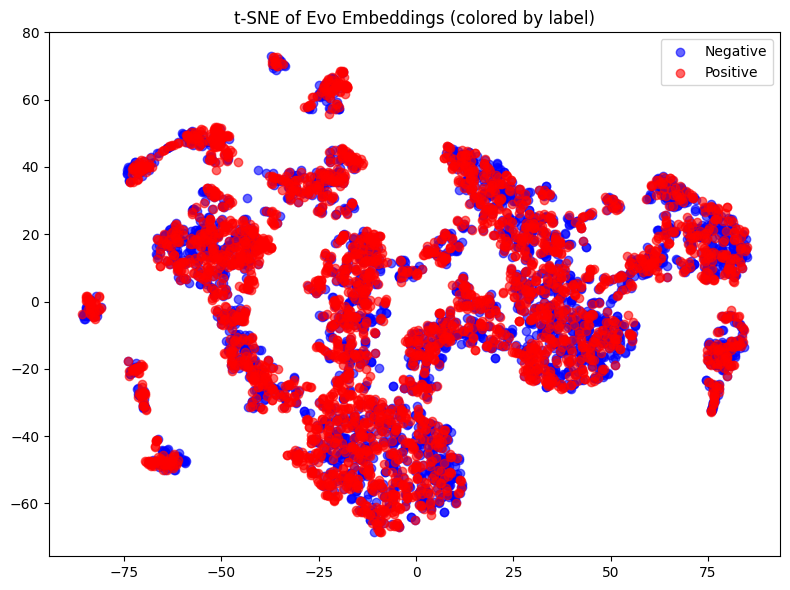

In [25]:
plt.figure(figsize=(8,6))
plt.title("t-SNE of Evo Embeddings (colored by label)")
plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1], label="Negative", c='blue', alpha=0.6)
plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1], label="Positive", c='red', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


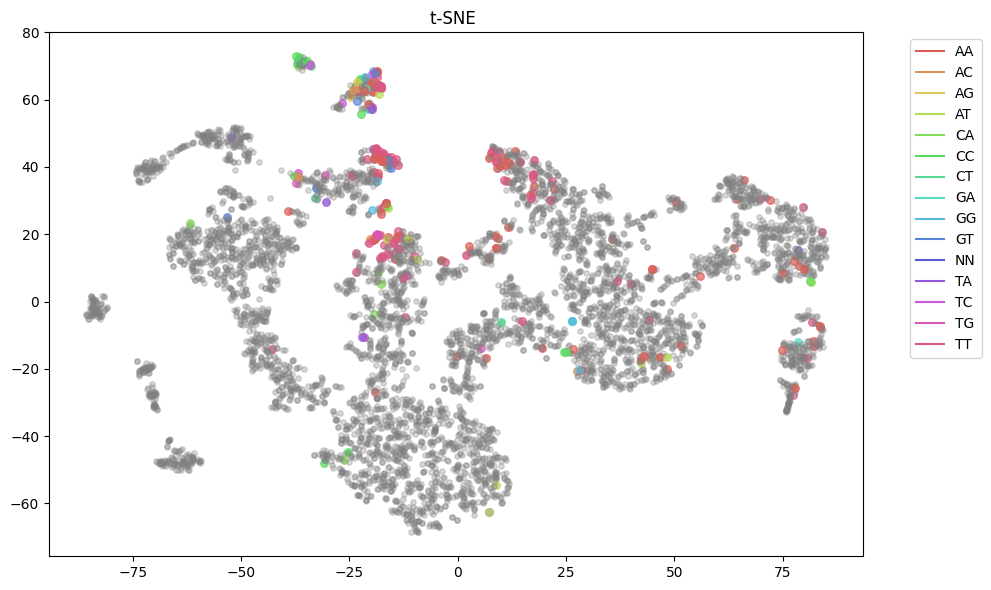

In [27]:
plt.figure(figsize=(10,6))
plt.title("t-SNE ")

unique_nmers = sorted(set([n for n in dominant_nmers if n is not None]))
palette = sns.color_palette("hls", len(unique_nmers))
nmer_color_map = {n: palette[i] for i, n in enumerate(unique_nmers)}

for i, (pt, nmer) in enumerate(zip(X_tsne, dominant_nmers)):
    if nmer in nmer_color_map:
        plt.scatter(pt[0], pt[1], color=nmer_color_map[nmer], s=30, alpha=0.7)
    else:
        plt.scatter(pt[0], pt[1], color='grey', s=15, alpha=0.3)

handles = [plt.Line2D([], [], color=col, label=nm) for nm, col in nmer_color_map.items()]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


 2-mers (e.g., "AA", "TT") tend to concentrate in specific regions of the embedding space. 

Utilize a clustering algorithm (e.g. K-means, Leiden, H-DBSCAN) to cluster the embeddings. Is the clustering reflected on the UMAP? Plot the proportions of your chosen n-nucleotide in each of the cluster. 

In [28]:
from sklearn.cluster import KMeans
import numpy as np
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X)  


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [30]:
from collections import defaultdict, Counter

cluster_to_nmers = defaultdict(list)
for cluster, nmer in zip(cluster_labels, dominant_nmers):
    if nmer is not None:
        cluster_to_nmers[cluster].append(nmer)

for c in sorted(cluster_to_nmers):
    count = Counter(cluster_to_nmers[c])
    total = sum(count.values())
    print(f"Cluster {c} ({total} sequences):")
    for nmer, freq in count.most_common(5):
        print(f"  {nmer}: {freq} ({freq / total:.2%})")


Cluster 0 (21 sequences):
  AA: 4 (19.05%)
  CC: 3 (14.29%)
  CA: 2 (9.52%)
  GT: 2 (9.52%)
  TA: 2 (9.52%)
Cluster 2 (157 sequences):
  TT: 54 (34.39%)
  AA: 40 (25.48%)
  CC: 8 (5.10%)
  CT: 7 (4.46%)
  GG: 7 (4.46%)
Cluster 3 (72 sequences):
  TT: 34 (47.22%)
  AA: 30 (41.67%)
  CA: 3 (4.17%)
  TA: 2 (2.78%)
  TG: 1 (1.39%)
Cluster 4 (47 sequences):
  AA: 24 (51.06%)
  TT: 9 (19.15%)
  CC: 3 (6.38%)
  GG: 3 (6.38%)
  AT: 2 (4.26%)


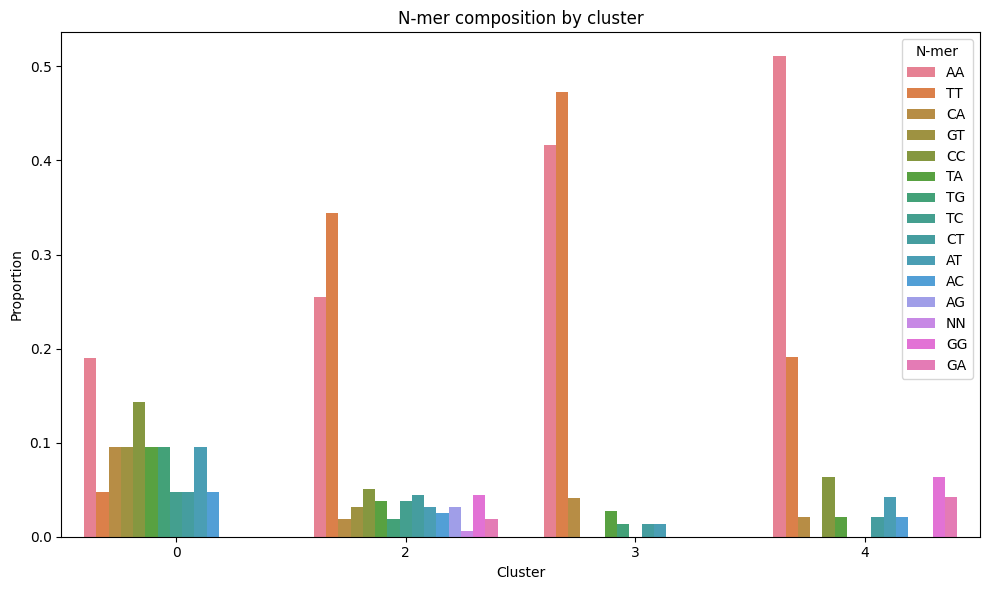

In [31]:
import seaborn as sns
import pandas as pd

records = []
for c, nmers in cluster_to_nmers.items():
    count = Counter(nmers)
    total = sum(count.values())
    for nmer, freq in count.items():
        records.append({"Cluster": c, "N-mer": nmer, "Proportion": freq / total})

df = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Cluster", y="Proportion", hue="N-mer")
plt.title("N-mer composition by cluster")
plt.tight_layout()
plt.show()


Yes, the clustering is reflected on the UMAP projection.

#### Train on top of the embeddings (10 points):

Did we even need the pre-trained transformer at all?

Training a multi-layer MLP on top of the embeddings to classify enhancer from non-enhancer sequences. How does it compare to the models you already trained based on accuracy, AUC, runtime and memory requirements?

In [32]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.load("evo_embeddings.npy")  
y = np.load("evo_labels.npy")    

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
import torch
import torch.nn as nn
import time
from sklearn.metrics import accuracy_score, roc_auc_score
import psutil

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.net(x)


In [34]:
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

model = MLPClassifier(input_dim=X.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

start_time = time.time()
for epoch in range(10):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()

train_time = time.time() - start_time

model.eval()
y_true, y_prob = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        y_prob.extend(probs)
        y_true.extend(yb.numpy())

y_pred = [1 if p >= 0.5 else 0 for p in y_prob]
acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)


if torch.cuda.is_available():
    mem_used = torch.cuda.max_memory_allocated() / 1024**2
else:
    mem_used = psutil.Process().memory_info().rss / 1024**2

print(f"MLP on Evo Embedding → Accuracy: {acc:.4f}, AUC: {auc:.4f}, Train Time: {train_time:.2f}s, Memory: {mem_used:.2f} MB")


MLP on Evo Embedding → Accuracy: 0.5077, AUC: 0.5000, Train Time: 1.50s, Memory: 22731.05 MB


The Accuracy and AUC is much lower than the previous models. MLP need large memory.